# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
import os
import sys
from pprint import pprint

# so that mllm_shap can be imported without installing the package
sys.path.insert(0, os.path.abspath("../mllm_shap/src"))

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TQDM_DISABLE"] = "1"
os.environ["LOG_LEVEL"] = "INFO"

In [3]:
import numpy as np
import pandas as pd
import torch

np.random.seed(42)

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"Using device: {device}")

Using device: mps


In [ ]:
from mllm_shap.connectors import LiquidAudio, ModelConfig
from mllm_shap.connectors.enums import ModelHistoryTrackingMode, Role, SystemRolesSetup
from mllm_shap.connectors.filters import ExcludePunctuationTokensFilter
from mllm_shap.shap import Explainer, McShapExplainer
from mllm_shap.shap.embeddings import MeanReducer
from mllm_shap.shap.enums import Mode
from mllm_shap.shap.normalizers import AbsSumNormalizer
from mllm_shap.shap.similarity import CosineSimilarity
from mllm_shap.utils.audio import display_audio
from mllm_shap.utils.jupyter import display_shap_colors_df, display_shap_colors_df_audio, plot_distribution

# Usage

Define LiquidAudio model (this call loads it up to the memory!).

Create compact explainer that will make initial call and then explain it using shapley values approximated using Monte Carlo. Set minimal number of samples for demo purpose, that is only one-versus-all (number of additional calls = number of tokens to explain + 1 for empty call).

AbsSumNormalizer divides each value by sum of abs shapley values.

In [ ]:
model = LiquidAudio(
    device=device, history_tracking_mode=ModelHistoryTrackingMode.AUDIO
)  # track and generate only audio history
shap = McShapExplainer(
    num_samples=-1,
    mode=Mode.CONTEXTUAL,  # use contextual embeddings, default
    # use mean pooling to reduce token embeddings to single embedding per audio, default
    embedding_reducer=MeanReducer(),
    similarity_measure=CosineSimilarity(),  # use cosine similarity to compare embeddings, default
    normalizer=AbsSumNormalizer(),  # use abs sum normalizer to normalize shap values
)
explainer = Explainer(model=model, shap_explainer=shap)

W1021 22:23:21.295000 3466 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Create new chat that treats Assistant messages as system, that is will ignore them for shapley values calculation - they will be feed to each prompt as system messages. This significantly reduces number of requests needed for multi turn expandability, yet might not be possible due to business requirements. 

To further reduce number of calls we exclude punctuation tokens.

In [6]:
chat = model.get_new_chat(
    system_roles_setup=SystemRolesSetup.SYSTEM,  # explain assistant responses as well
    token_filter=ExcludePunctuationTokensFilter(),  # exclude punctuation tokens from shapley values calculation
)

chat.new_turn(Role.SYSTEM)
chat.add_text("You are a helpful assistant that answers questions briefly.")
chat.end_turn()

chat.new_turn(Role.USER)
chat.add_text("Who are you?")
chat.end_turn()

Let's have a look at chat representation:

In [7]:
pprint(chat.get_conversation())

[[ChatEntry(content_type=0, roles=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], content='<|im_start|>, system, \n, You,  are,  a,  helpful,  assistant,  that,  answers,  questions,  briefly...', shap_values=None)],
 [ChatEntry(content_type=0, roles=[2, 2, 2, 0, 0, 0, 0, 2, 2], content='<|im_start|>, user, \n, Who,  are,  you, ?, <|im_end|>, \n', shap_values=None)]]


Representation is a list of list of ConversationEntry - so it can be accessed as  chat.get_conversation()[turn_number][message_number].{field}

Let's calculate shapley values for current conversation.

Verbose=True allows us to access history object (descried later). Generation kwargs allows to customize model interference - here we limit it to 16 tokens and change text_temperature from default 0.0 to 0.2. 

In [8]:
generation_kwargs = {"max_new_tokens": 32, "model_config": ModelConfig(text_temperature=0.2)}

result = explainer(
    chat=chat,
    verbose=True,
    generation_kwargs=generation_kwargs,
    progress_bar=True,  # show progress bar during generation, default
)

2025-10-21 22:23:27,191 - mllm_shap.shap.compact - INFO - Generating full response from the model...
2025-10-21 22:23:29,917 - mllm_shap.shap._base.explainer - INFO - Number of tokens for explainability: 3, (up to 7 additional calls)


Calculating SHAP values:   0%|          | 0/4 [00:00<?, ?it/s]

Result has now following fields available:

- full_chat - chat with base response (generated based on whole entry) with set cache and calculated shapley values
- response_chat - chat with just last turn of full_chat, that is generated model response
- source_chat - original chat feed to the explainer
- history - history of all chats used

Let's first analyze history - it is a list of size equivalent to number of additional calls made for calculations (in this case, 4). Each entry is a tuple of 5 following values:

- mask for that entry
- source chat with masked entry
- chat of only model response
- source chat with masked entry and model response
- embeddings of chat response (reduced)

Let's see all chats that were taken into account:

In [9]:
pprint([c[1].decode_text() if c is not None else None for c in result.history])

[None,
 '<|startoftext|><|im_start|>system\n'
 'You are a helpful assistant that answers questions briefly.<|im_end|>\n'
 '<|im_start|>user\n'
 '?<|im_end|>\n',
 '<|startoftext|><|im_start|>system\n'
 'You are a helpful assistant that answers questions briefly.<|im_end|>\n'
 '<|im_start|>user\n'
 'Who?<|im_end|>\n',
 '<|startoftext|><|im_start|>system\n'
 'You are a helpful assistant that answers questions briefly.<|im_end|>\n'
 '<|im_start|>user\n'
 ' are?<|im_end|>\n',
 '<|startoftext|><|im_start|>system\n'
 'You are a helpful assistant that answers questions briefly.<|im_end|>\n'
 '<|im_start|>user\n'
 ' you?<|im_end|>\n']


In [10]:
explained_chat = result.full_chat

explained_chat_conversation = explained_chat.get_conversation()
pprint(explained_chat_conversation)

[[ChatEntry(content_type=0, roles=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], content='<|im_start|>, system, \n, You,  are,  a,  helpful,  assistant,  that,  answers,  questions,  briefly...', shap_values=[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])],
 [ChatEntry(content_type=0, roles=[2, 2, 2, 0, 0, 0, 0, 2, 2], content='<|im_start|>, user, \n, Who,  are,  you, ?, <|im_end|>, \n', shap_values=[nan, nan, nan, 0.3125, 0.376953125, 0.3125, nan, nan, nan])],
 [ChatEntry(content_type=0, roles=[2, 2, 2], content='<|im_start|>, assistant, \n', shap_values=[nan, nan, nan]),
  ChatEntry(content_type=1, roles=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], content='Audio bytes of total length 24624', shap_values=[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan]),
  ChatEntry(content_type=0, roles=[2, 2], content='<|im_end|>, \n', shap_values=[nan, nan])]]


In [11]:
explained_chat_conversation[1][0].display()

BY: USER, SYSTEM
TEXT CONTENT:
	<|im_start|> user 
	 Who  are  you ? <|im_end|> 
	


In [12]:
explained_chat_conversation[2][1].display()

BY: ASSISTANT
AUDIO CONTENT:


In [14]:
display_audio(explained_chat.decode_audio(explained_chat.audio_out))

Model was set to return just text tokens, so chat history has only text tokens. We can see that in the json representation inside ConversationEntry shap_values field is now populated. Nan values indicated that this token wasn't taken into calculation scope. As expected, we have 3 not-nan tokens. Let's see them.

In [15]:
user_entry = explained_chat_conversation[1][0]

display_shap_colors_df(
    pd.DataFrame(list(zip(user_entry.content, user_entry.shap_values)), columns=["Token", "Shapley Value"])
)

,Token,Shapley Value
0,<|im_start|>,nan
1,user,nan
2,,nan
3,Who,0.312500
4,are,0.376953
5,you,0.312500
6,?,nan
7,<|im_end|>,nan
8,,nan


Let's create another turn to see how input significance will change:

In [16]:
explained_chat.new_turn(Role.USER)
explained_chat.add_text("Can you repeat?")
explained_chat.end_turn()

And again, let's explain it:

In [17]:
result = explainer(chat=explained_chat, verbose=False, generation_kwargs=generation_kwargs)

2025-10-21 22:23:59,636 - mllm_shap.shap.compact - INFO - Generating full response from the model...
2025-10-21 22:24:02,573 - mllm_shap.shap._base.explainer - INFO - Number of tokens for explainability: 26, (up to 67108863 additional calls)
2025-10-21 22:24:02,691 - mllm_shap.shap._base.explainer - INFO - Deduplicated 0/27 masks using existing cache.


Calculating SHAP values:   0%|          | 0/27 [00:00<?, ?it/s]

In [18]:
explained_chat = result.full_chat

explained_chat_conversation = explained_chat.get_conversation()
pprint(explained_chat_conversation)

[[ChatEntry(content_type=0, roles=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], content='<|im_start|>, system, \n, You,  are,  a,  helpful,  assistant,  that,  answers,  questions,  briefly...', shap_values=[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])],
 [ChatEntry(content_type=0, roles=[2, 2, 2, 0, 0, 0, 0, 2, 2], content='<|im_start|>, user, \n, Who,  are,  you, ?, <|im_end|>, \n', shap_values=[nan, nan, nan, 0.052734375, 0.055908203125, 0.052734375, nan, nan, nan])],
 [ChatEntry(content_type=0, roles=[2, 2, 2], content='<|im_start|>, assistant, \n', shap_values=[nan, nan, nan]),
  ChatEntry(content_type=1, roles=[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], content='Audio bytes of total length 24624', shap_values=[0.0296630859375, 0.055908203125, 0.046142578125, 0.0296630859375, 0.0296630859375, 0.042724609375, 0.0361328125, 0.0296630859375, 0.052734375, 0.0361328125, 0.0361328125, 0.0296630859375, 0.0296630859375, 0.052734375, 0.0527

Let's have a look at shapley values for text representation:

In [19]:
dt = []
for i in (1, 3):
    user_entry = explained_chat_conversation[i][0]
    df = pd.DataFrame(list(zip(user_entry.content, user_entry.shap_values)), columns=["Token", "Shapley Value"])
    df["Turn"] = i
    dt.append(df)

df = pd.concat(dt).reset_index(drop=True)

display_shap_colors_df(df)

,Token,Shapley Value,Turn
0,<|im_start|>,nan,1
1,user,nan,1
2,,nan,1
3,Who,0.052734,1
4,are,0.055908,1
5,you,0.052734,1
6,?,nan,1
7,<|im_end|>,nan,1
8,,nan,1
9,<|im_start|>,nan,3


In [20]:
audio_to_explain = explained_chat_conversation[2][1]

display_shap_colors_df_audio(
    pd.DataFrame(list(zip(audio_to_explain.content, audio_to_explain.shap_values)), columns=["Audio", "Shapley Value"])
)

,Audio,Shapley Value
0,"<source src=""data:audio/wav;base64,//OExAAAAAAAAAAAAFhpbmcAAAAPAAAABgAABtgANzc3Nzc3Nzc3Nzc3Nzc3N25ubm5ubm5ubm5ubm5ubm5unZ2dnZ2dnZ2dnZ2dnZ2dndTU1NTU1NTU1NTU1NTU1NTU/Pz8/Pz8/Pz8/Pz8/Pz8/Pz/////////////////////AAAAPExBTUUzLjEwMAR4AAAAAAAAAAAVCCQDwCEAAcwAAAbYslJ4awAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA//O0xAAWqFKAV0YAADEm4J/w5MBgMnf/iDCBAgg5AgGAQOA4clwfBA5gmD7/yjoPwfB/KOg/xAc6wfBDUXD//Lg+D4IAgCAIAMHwffwQBABg+D//pBAEAQ/B9+BHSgIB+XB8CAgGP0IEVgAPBQFgpKNyWOaT4y4HEgYwiGLAaZRLmMg5lIyZ4NGGigNTQSHCQ8iERDoMCBUdMiNE1EBqgZfM4dA/Y2QHBS7YAtRM2nRzlJZZDISCVpV8sxwH3d5to1Aiwiji+4MVM5bkTkH4xOBptud2airTV5SumxjT2PfA0Z+QSp+4zB3yqM24BaJQWKSs+09I6WntvnaxfmbtzENRSrNR2KTEpvS+NSaHpijjsR1OPwseP0kbgiS5T9WP08obpAWPNSzeW5RCLFFOY2NTc525UpftU1XGU001TYwJKa1NKqWlpp+JX52NZzET//O0xOhNVDp+X5vIAKSfppqzLbeD72LdByLZbuZXL34W6Wmympndntq1jjyp+F7+a38skcQqU0IpqKYt73vOHqCzY3T54SyRRadf2XXpfvL8ZRYn5ikq/PZW6gEFgAEgAkYFZO7noIQnSbJr/2YAPmNMwCbS26NJiB2YwrGoCZsJSpeLBZgJ8aquCMcAgUgETocg02VVwEkHpBwCI7Tl2NASvXKmanKnWxxt1AES2JvPRRunbuiawZgzXkeIpCInmyx3KKRyiKNkLrAIZlK1WcwtuDiSqdjbO3/o4dr08MXYBZzHpdWp5M/8vmaPDJ2LFuXT85jL5RIp9y5mLORKJa7USi0lzkEqnLunElsT3lF5iilseppunlknu5SyMRrcruWYa1bt09PhSXO2857/rW/1hrdvPPeMomJXQU0OTcrrYUVya3TdsS+S1Od5T2rd//OkxPVHxBKSP5vIITY3M7dn8v3+fP/+/++f3XcN/3LePLX/3+//P//7///97h3+7t/b06fjswgAACAACTZNJ2sZ2umICRlz4KgRjoGNBQKaTPCExMhCDdKMFARmaCZYZGyBRktCBQUwIoOKCIohlQppHpIuIS5eYu+pYWA4UMApob4oZZCVXS8BsgtEvs0EviBDIkCFhSlhasaxiwRCFM9gqDz61XVeYsBRGAMUEWk3Fq6KqdZgACplh1cMSZDATpQ3GFfMQTTV6uuGIacJnaqiXzuz0Ssv0+T8xa7VfmH5e/leBZ6MVoEdeblkP1csar+P3Dz+xaRS2amoZgarTSyYuwfco7FBMUE7hEI9DdjKbppdT48msbFztbO5FozY//O0xOlP/BKdf5vRIbGFJhRU32Mp36L7kVkVe5u9T6wxsWpm9lUltTKtNy6MyqJTdJZpqGrcsWa9NR0ler2kx+plq39Tl63Uxw3hr/1hay5vut4Z/3fz9rHLfcbsxQ3uQJsXTQPgPgDwHQIAQAgWLh+NA2DNNAx+BSxmRESrgE40xFIvrMUxmVB1F7VjAkpmDAN0nAwQABpMJuE5DpMk2AwpYAVSBhnAf4c4QhE4mXg2eDUR1iCofgZl0ok6Or4mwHBg0EMujMC3k0Q0uGRsd/D0hGYWSEEFiH8py6RxSNkUf4bwLcKWH8lhYSBEFHWeKK2JpS0V/8hwyQ5BwUGZjPk8WCICtBlC6xkTx0ySooE0Zf/k2TLE4YjrHOGXMJ0nzpSLpGJJLRR+jqr//9MtrQRQu55EAnw8dC4FsxUFcqpMQU1FMy4xMDCqqqqqqqqq//OUxOw2216rH5qhIKqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqqq//MUxPMAAANIAcAAAKqqqqqqqqqqqqqq"" type=""audio/wav"" /> Your browser does not support the audio element.",0.029663
1,"<source src=""data:audio/wav;base64,//OExAAAAAAAAAAAAFhpbmcAAAAPAAAABgAABkgAPDw8PDw8PDw8PDw8PDw8PHl5eXl5eXl5eXl5eXl5eXl5pKSkpKSkpKSkpKSkpKSkpMfHx8fHx8fHx8fHx8fHx8fH+/v7+/v7+/v7+/v7+/v7+/v/////////////////////AAAAPExBTUUzLjEwMAR4AAAAAAAAAAAVCCQDwCEAAcwAAAZIFsSSCAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA//O0xAAVyHaEN0wwAAqkE/xIPISWIYNwbiWTxIEgGhMdHMCYjpgJgfP8pzb+A5MCAgcEgYiCCEHw+Xfw/y4Pn1Qx/8uDgY4P/+D4PgQEAQdA4Pn+UOQff/+UBD8u/Ju4DfpBByoACOJCCDUTzjSUBxJN9GYxwTwcfFBgUPwCDDIR6EEbBxdMVhEAp8yqFjWlYN9D8SwYJM5h5MShJiw0Y0ABmKdZ8GHCwhGAqhmLCBgYKgMh0+qKN/QDNhUEBhi5IRJgcGr3d544JXSx5kjaLeehiiRaioUAlHlbE6nhdpUzXYIHEECpAFEyEGU4RoWeLHaAVh2DAZa/zD14tIj94KBZgQkYuRmQkgGJWkMlbEy4YCW5uzjelUXhbeSt+m0eaahyVUaPyOqJ6MLtZc/OXUcahV24l/GNT17HHtf7L+N0tyrd7m8KsaiMXf1it3ut//O0xOtW1DaAV5zYIP5YVpW9l17mrymEQFFo5SxSM3KaNVZa11rUWg+rA0RiE3TU9vW8fi0Xpp+VTsqppfapsMLXLb6w1KnalMRitNLpdjSzuGdNZx5rPsXkduxK4hqghEi7urlVwx1T09+9TP/QS6KR69PfTZ5fz/ys/NcqQM5gzOk9CYk4SmQ02DhLeEjVU68DIWzxYDEghEPMD2HRylgoHIlLeJDAaCDAKTZmsIAwwAAYAo+BaqHAhywZZHNFzChCOIGREhSsREvIEOJ9MjCeJw8OIvmgtIjwwDvh7Q7h1jLDYIoOsgpaK45pmXiLFch5KD2KeLohxFRAUc0d5mTBsdUcOpI9t1slPGyjAxmhdLhoeUXTNZw6iZLUpJf///177p3TtdF3OhwVOi4fV/xcs88VMywM69+bTG1KSQSCdTxK2g1zcSPXGxhxaR1w//OUxNIxoqqAB9qgAEFY2/gyfib/AA4fYmrS1sRnVaKIvuiTKYkNF4k1wAQGWxhVciEz9824GmfWnjl6Rd4i63abcN9ljLEuFwJ40v297SGrsVl9JX2IiGt6tfmqAYMiwtArMf//P1xzYy7xUyD1gJpEg65VuafqYp4mquu/+P+oeGT7Tn4uJmXKSEPuErT9P63j9+7mUEo756f8tuz3j3aDWhYhqBGR4TNb68ZUjkoAXiEAmyYAeZASq0QgjHlgEiXkYpKagWYVgceUbsoDC5MUQqUxSdMULDAMAF/i2QCBLHMIZMmOGRpokoYpWGp3//OExO4rY

Let's finally plot shapley values distribution:

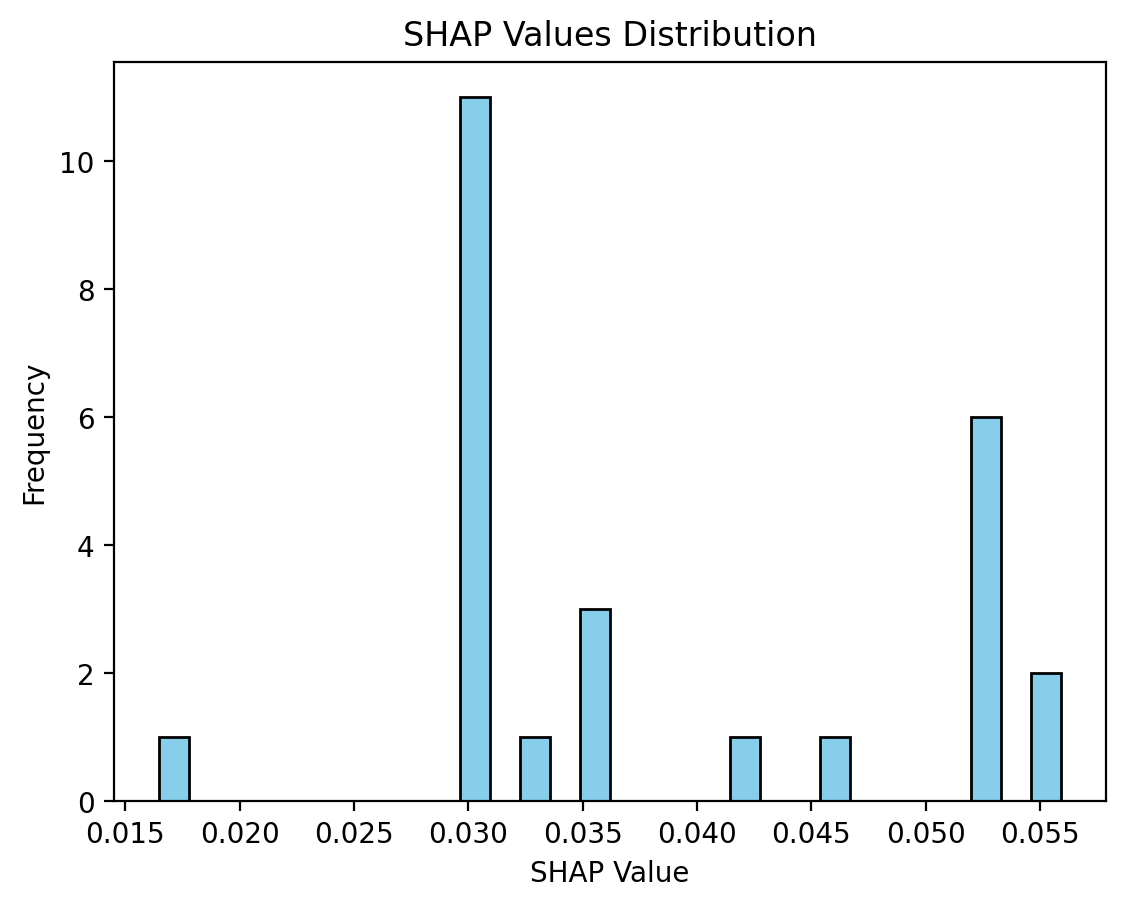

In [22]:
sv = explained_chat.shap.normalized_values
sv = sv[~torch.isnan(sv)]

plot_distribution(sv, bins=30, color="skyblue", edgecolor="black")